In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Dense, Dropout,
    BatchNormalization, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F


%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/DL_Project

/content/drive/MyDrive/DL_Project


# constants

In [ ]:
IMG_SIZE = 224
DATA_DIR = "dataset"

TRAIN_DIR = "train"
VAL_DIR   = "val"
TEST_DIR  = "test"

# **1- Preprocessing (CLAHE)**

In [ ]:
def equalize(img):
    img = img.astype(np.uint8)
    clahe = cv2.createCLAHE(tileGridSize=(8,8))
    img = clahe.apply(img)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

In [ ]:
def compare_equalized(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    eq = equalize(img).squeeze()
    both = np.hstack([img, eq])

    plt.figure(figsize=(8,4))
    plt.imshow(both, cmap='gray')
    plt.axis('off')
    plt.show()

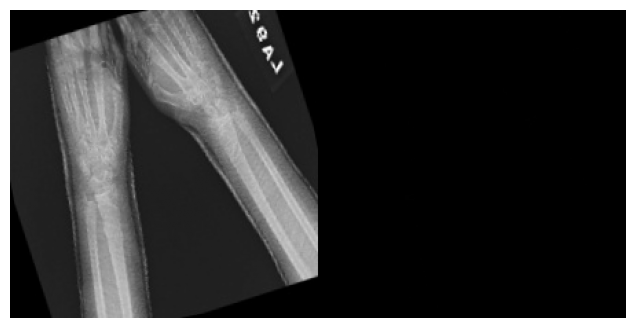

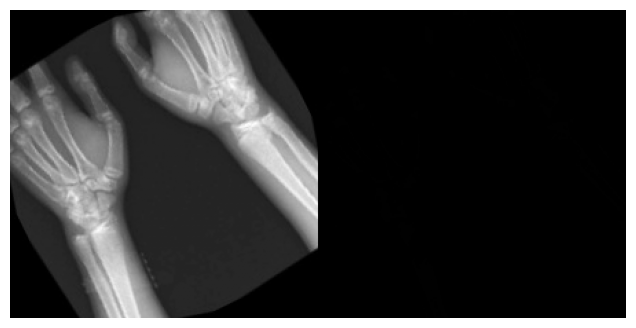

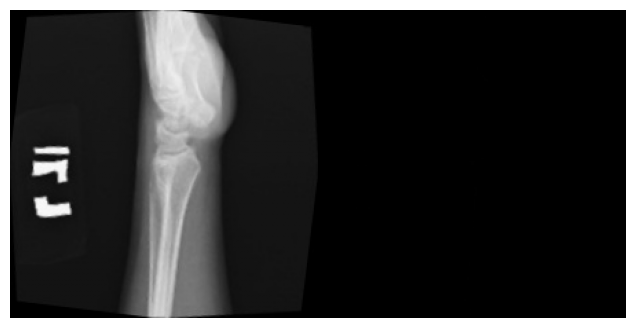

In [ ]:
compare_equalized("dataset/val/fractured/3-rotated2-rotated1.jpg")
compare_equalized("dataset/val/fractured/97-rotated3-rotated3-rotated3.jpg")
compare_equalized("dataset/val/fractured/99-rotated2-rotated2-rotated1 - Copy.jpg")

## **2- Data Generators**

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=equalize,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=equalize)
test_datagen = ImageDataGenerator(preprocessing_function=equalize)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, TRAIN_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, VAL_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, TEST_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=32,
    shuffle=False,
    class_mode='categorical'
)

Found 288 images belonging to 2 classes.
Found 61 images belonging to 2 classes.
Found 63 images belonging to 2 classes.


## **3- Advanced CNN**

In [ ]:
model = Sequential()

model.add(Conv2D(32, 3, padding='same', input_shape=(224,224,1)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D())
model.add(Dropout(0.25))

model.add(Conv2D(64, 3, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D())
model.add(Dropout(0.25))

model.add(Conv2D(128, 3, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPool2D())
model.add(Dropout(0.3))

model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC()
    ]
)

### **4- Training Model**

In [ ]:
callbacks = [
    EarlyStopping(patience=12, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5),
    ModelCheckpoint("model_bone.h5", save_best_only=True)
]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5597 - auc: 0.5753 - loss: 0.9025 - precision: 0.5597 - recall: 0.5597

9/9 ━━━━━━━━━━━━━━━━━━━━ 91s 9s/step - accuracy: 0.5579 - auc: 0.5759 - loss: 0.8947 - precision: 0.5579 - recall: 0.5579 - val_accuracy: 0.5738 - val_auc: 0.5727 - val_loss: 0.6911 - val_precision: 0.5738 - val_recall: 0.5738 - learning_rate: 1.0000e-04
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4962 - auc: 0.4774 - loss: 0.8609 - precision: 0.4962 - recall: 0.4962

9/9 ━━━━━━━━━━━━━━━━━━━━ 62s 7s/step - accuracy: 0.4952 - auc: 0.4778 - loss: 0.8576 - precision: 0.4952 - recall: 0.4952 - val_accuracy: 0.5738 - val_auc: 0.5552 - val_loss: 0.6855 - val_precision: 0.5738 - val_recall: 0.5738 - learning_rate: 1.0000e-04
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5037 - auc: 0.5266 - loss: 0.7830 - precision: 0.5037 - recall: 0.5037

9/9 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 0.5044 - auc: 0.5273 - loss: 0.7824 - precision: 0.5044 - recall: 0.5044 - val_accuracy: 0.5738 - val_auc: 0.6060 - val_loss: 0.6824 - val_precision: 0.5738 - val_recall: 0.5738 - learning_rate: 1.0000e-04
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 0.4979 - auc: 0.5303 - loss: 0.7551 - precision: 0.4979 - recall: 0.4979 - val_accuracy: 0.5738 - val_auc: 0.5343 - val_loss: 0.6849 - val_precision: 0.5738 - val_recall: 0.5738 - learning_rate: 1.0000e-04
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.5407 - auc: 0.5763 - loss: 0.7461 - precision: 0.5407 - recall: 0.5407 - val_accuracy: 0.5738 - val_auc: 0.5832 - val_loss: 0.6915 - val_precision: 0.5738 - val_recall: 0.5738 - learning_rate: 1.0000e-04
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 55s 6s/step - accuracy: 0.6120 - auc: 0.6017 - loss: 0.7075 - precision: 0.6120 - recall: 0.6120 - val_accuracy: 0.5738 - val_auc: 0.5848 - val_loss: 0.7039 - val_precision: 0.5

### **5- Training Curves**

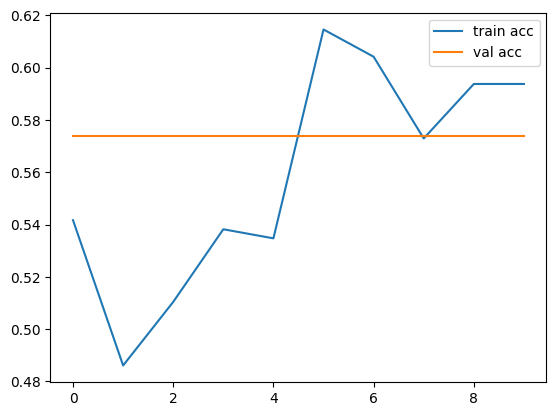

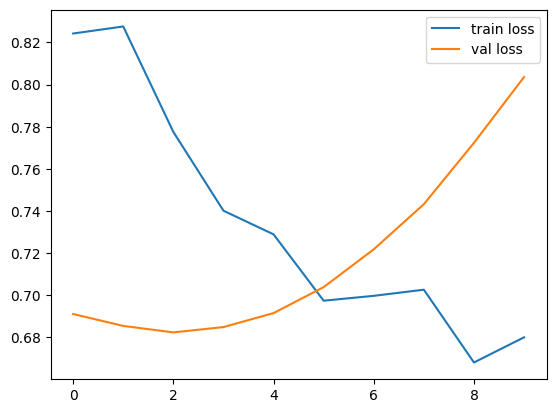

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

### **6- Evaluation**

In [ ]:
model.evaluate(test_gen)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 894ms/step - accuracy: 0.4330 - auc: 0.4777 - loss: 0.7223 - precision: 0.4330 - recall: 0.4330


[0.6825674176216125,
 0.5714285969734192,
 0.5714285969734192,
 0.5714285969734192,
 0.6061980128288269]

## **7- Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = test_gen.classes
y_pred = model.predict(test_gen)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.57      1.00      0.73        36

    accuracy                           0.57        63
   macro avg       0.29      0.50      0.36        63
weighted avg       0.33      0.57      0.42        63



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


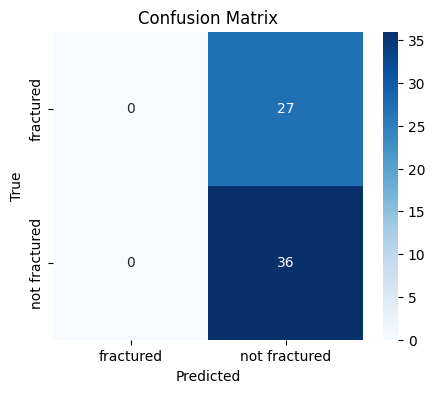

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


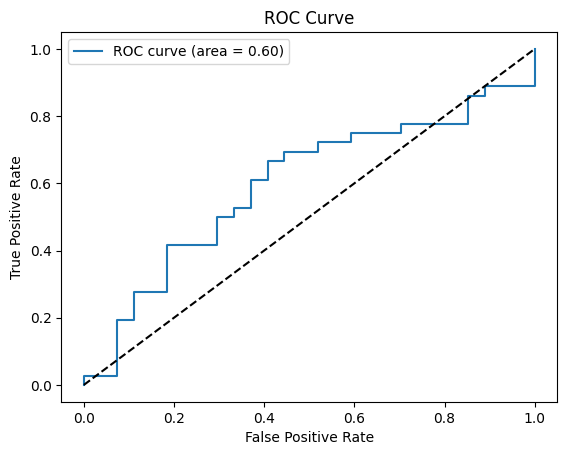

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(test_gen)

fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## **8- Single Image Prediction**

In [ ]:
def predict_single_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224,224))
    img = equalize(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return model.predict(img)

In [ ]:
class_names = list(test_gen.class_indices.keys())

pred = predict_single_image("dataset/test/fractured/92-rotated3-rotated3-rotated3.jpg")
pred_class = np.argmax(pred)
print("Predicted Class:", class_names[pred_class])
print("Confidence:", pred[0][pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
Predicted Class: not fractured
Confidence: 0.57885885
